In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df=pd.read_csv("credit_risk_dataset.csv")
df.sample(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1129,23,24996,OWN,1.0,EDUCATION,B,8000,11.26,0,0.32,N,2
1987,23,87000,RENT,4.0,EDUCATION,C,2100,NaN,0,0.02,N,2
11812,25,76000,MORTGAGE,3.0,PERSONAL,A,20000,6.54,0,0.26,N,4
7327,20,42000,RENT,4.0,VENTURE,B,6500,11.71,0,0.15,N,2
29392,36,25000,MORTGAGE,4.0,MEDICAL,A,11500,7.29,0,0.46,N,12


Data Preprocessing

In [3]:
df.shape

(32581, 12)

In [15]:
df.isnull().values.any()


np.True_

In [17]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


Filling missing values

In [18]:
for col in ['loan_int_rate', 'person_emp_length']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

df.isnull().sum()

/tmp/ipykernel_713/982896632.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [21]:
x=df.drop('loan_status', axis=1)
y=df['loan_status']

print(x)

print("target column ")
print(y)

       person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  \
0           

loan_status
0    25473
1     7108
Name: count, dtype: int64


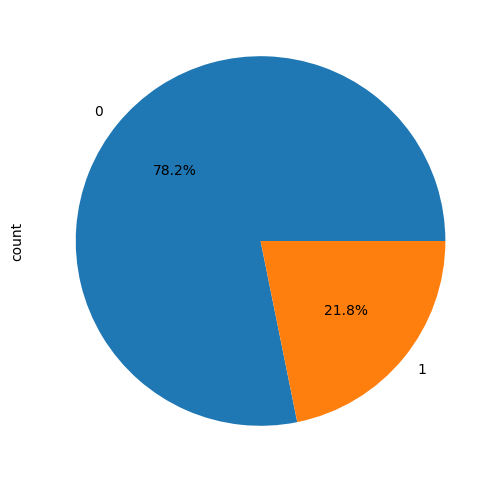

In [25]:
value_counts=y.value_counts()
print(value_counts)

plt.figure(figsize=(8,6))
value_counts.plot.pie(autopct='%1.1f%%')
plt.show()

In [27]:
x=pd.get_dummies(x)
print(x)

       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0              22          59000              123.0      35000          16.02   
1              21           9600                5.0       1000          11.14   
2              25           9600                1.0       5500          12.87   
3              23          65500                4.0      35000          15.23   
4              24          54400                8.0      35000          14.27   
...           ...            ...                ...        ...            ...   
32576          57          53000                1.0       5800          13.16   
32577          54         120000                4.0      17625           7.49   
32578          65          76000                3.0      35000          10.99   
32579          56         150000                5.0      15000          11.48   
32580          66          42000                2.0       6475           9.99   

       loan_percent_income 

Feature Selection through Mutual Information

In [28]:

from sklearn.feature_selection import mutual_info_classif
mutual_info= mutual_info_classif(x,y)
mutual_info= pd.Series(mutual_info, index= x.columns)
mutual_info.sort_values(ascending=False)

,0
person_income,0.111275
loan_percent_income,0.082755
loan_int_rate,0.067020
loan_grade_D,0.041391
person_home_ownership_RENT,0.031005
loan_grade_A,0.026578
person_home_ownership_MORTGAGE,0.020176
cb_person_default_on_file_N,0.019184
loan_amnt,0.018416
loan_grade_E,0.016941


In [30]:
from sklearn.feature_selection import SelectKBest

selector = SelectKBest(mutual_info_classif, k=16) # Example: selecting top 5 features
selector.fit(x, y)

SelectKBest(k=16, score_func=<function mutual_info_classif at 0x787083d15260>)

In [31]:

selected_features = selector.get_support()
selected_feature_names = x.columns[selected_features]
print(selected_feature_names)

Index(['person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate',
       'loan_percent_income', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_DEBTCONSOLIDATION', 'loan_intent_VENTURE', 'loan_grade_A',
       'loan_grade_D', 'loan_grade_E', 'loan_grade_F',
       'cb_person_default_on_file_N', 'cb_person_default_on_file_Y'],
      dtype='object')


In [32]:
x_new= x[selected_feature_names]
x_new

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,person_home_ownership_MORTGAGE,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_VENTURE,loan_grade_A,loan_grade_D,loan_grade_E,loan_grade_F,cb_person_default_on_file_N,cb_person_default_on_file_Y
0,59000,123.0,35000,16.02,0.59,False,False,True,False,False,False,True,False,False,False,True
1,9600,5.0,1000,11.14,0.10,False,True,False,False,False,False,False,False,False,True,False
2,9600,1.0,5500,12.87,0.57,True,False,False,False,False,False,False,False,False,True,False
3,65500,4.0,35000,15.23,0.53,False,False,True,False,False,False,False,False,False,True,False
4,54400,8.0,35000,14.27,0.55,False,False,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,53000,1.0,5800,13.16,0.11,True,False,False,False,False,False,False,False,False,True,False
32577,120000,4.0,17625,7.49,0.15,True,False,False,False,False,True,False,False,False,True,False
32578,76000,3.0,35000,10.99,0.46,False,False,True,False,False,False,False,False,False,True,False
32579,150000,5.0,15000,11.48,0.10,True,False,False,False,False,False,False,False,False,True,False


In [33]:


print(x_new.shape)
print(x.shape)

(32581, 16)
(32581, 26)


In [34]:
x_train,x_test,y_train,y_test= train_test_split(x_new, y, test_size=0.2, random_state=42)

Model Training

In [35]:
Ada= AdaBoostClassifier(n_estimators=100, random_state=42)
Ada.fit(x_train,y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [36]:
y_pred= Ada.predict(x_test)
accuracy_score(y_test,y_pred)

0.876783796225257

In [37]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.8768
Confusion Matrix:
 [[4826  246]
 [ 557  888]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      5072
           1       0.78      0.61      0.69      1445

    accuracy                           0.88      6517
   macro avg       0.84      0.78      0.81      6517
weighted avg       0.87      0.88      0.87      6517



In [38]:

train_acc= accuracy_score(y_train, Ada.predict(x_train))
test_acc= accuracy_score(y_test, y_pred)
print(train_acc)
print(test_acc)


0.8767265193370166
0.876783796225257


Smote sampling

In [41]:

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=3, random_state=42)

smt = SMOTETomek( smote=smote,random_state=42)

In [40]:
from collections import Counter
X_train_ns,y_train_ns=smt.fit_resample(x_train,y_train)
print("The number of classes before fit {}".format(Counter(y_train)))
print("The number of classes after fit {}".format(Counter(y_train_ns)))

The number of classes before fit Counter({0: 20401, 1: 5663})
The number of classes after fit Counter({0: 19319, 1: 19319})


In [44]:
# Double check the counts and shapes
print(f"Original training shape: {x_train.shape}")
print(f"Resampled training shape: {X_train_ns.shape}")
print(f"Class distribution: \n{y_train_ns.value_counts()}")

Original training shape: (26064, 16)
Resampled training shape: (38638, 16)
Class distribution: 
loan_status
0    19319
1    19319
Name: count, dtype: int64


In [ ]:

Ada= AdaBoostClassifier(n_estimators=1000)
Ada.fit(X_train_ns,y_train_ns)

In [42]:

y_pred= Ada.predict(x_test)
accuracy_score(y_test,y_pred)

0.876783796225257

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.8768
Confusion Matrix:
 [[4826  246]
 [ 557  888]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      5072
           1       0.78      0.61      0.69      1445

    accuracy                           0.88      6517
   macro avg       0.84      0.78      0.81      6517
weighted avg       0.87      0.88      0.87      6517

